# 1. Importing libraries & creating working paths

In [1]:
!pip install pyvis -q
!pip install -U kaleido -q
import sys
!{sys.executable} -m pip install scipy
import re
import os
import scipy
import glob

import spacy
from spacy import displacy

import pandas as pd
import seaborn as sns

from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import networkx as nx
from pyvis.network import Network
import community as community_louvain


!curl -o plt_style https://raw.githubusercontent.com/jishnukoliyadan/the_breaking_bad_network/master/src/plt_style


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100    83  100    83    0     0    256      0 --:--:-- --:--:-- --:--:--   256


In [2]:
! python -m spacy download en_core_web_sm -q

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [3]:
# Setting plot styles

plt.style.use(['fivethirtyeight', 'plt_style'])

In [4]:
# Creating directories for storing files

os.makedirs('src/htmls', exist_ok = True)
os.makedirs('src/plots', exist_ok = True)
os.makedirs('src/char_imp', exist_ok = True)
os.makedirs('data/summaries', exist_ok = True)
os.makedirs('data/gephi_files', exist_ok = True)

## 2.1 Loading data

In [5]:
character_df = pd.read_csv('../webscraping/data/character_df_cleaned.csv')
character_df.head()

,Arc,Character
0,Final Selection Arc,Nezuko Kamado
1,Final Selection Arc,Tanjiro Kamado
2,Final Selection Arc,Kie Kamado
3,Final Selection Arc,Shigeru Kamado
4,Final Selection Arc,Hanako Kamado


In [6]:
# Loading spaCy English language model

NER = spacy.load('en_core_web_sm')

In [7]:
# Reading season summary file

with open('../webscraping/data/summaries/Final Selection Arc.txt', 'r') as f:
    sea1_txt = f.read()
    
sea1_txt = sea1_txt.replace('\n', '\n. ')

In [8]:
# https://stackoverflow.com/a/51219483
# https://nanonets.com/blog/named-entity-recognition-with-nltk-and-spacy/ : For NLTK
from IPython.display import display
ner1 = NER(sea1_txt)

# Visualize the identidied entites

# displacy.render(ner1[:500], style = 'ent', jupyter = True)

## 2.2 Extracting and storing named entities.

In [9]:
# Looping through the sentences to create entity list and dataframe

entity_df = []

for sentence in ner1.sents:
    entity_lis = [ent.text for ent in sentence.ents]
    entity_df.append({'sentence' : sentence, 'entities' : entity_lis})
    
entity_df = pd.DataFrame(entity_df)
entity_df

,sentence,entities
0,"(A, young, boy, carries, a, visibly, -, wounde...",[]
1,"(This, girl, is, revealed, to, be, his, younge...",[Nezuko]
2,"(He, treks, frantically, through, the, snow, a...",[]
3,"(Tanjiro, Kamado, prepares, to, depart, his, h...",[Tanjiro Kamado]
4,"(As, New, Year, is, about, to, arrive, ,, Tanj...","[New Year, Tanjiro Kamado]"
...,...,...
308,"(Haganezuka, mentions, that, Nichirin, Sword, ...","[Haganezuka, Nichirin Sword]"
309,"(Upon, revealing, the, blade, ,, Tanjiro, watc...",[Tanjiro]
310,"(Hearing, Sakonji, 's, and, Haganezuka, 's, re...","[Sakonji, Haganezuka]"
311,"(However, ,, Haganezuka, is, less, than, pleas...","[Haganezuka, Tanjiro]"


## 2.3 Filtering entities based on `character_df`

In [10]:
problem_rows = character_df[~character_df['Character'].apply(lambda x: isinstance(x, str) and x.strip() != '')]

print(len(problem_rows))

character_df = character_df[character_df['Character'].apply(lambda x: isinstance(x, str) and x.strip() != '')].copy()

problem_rows = character_df[~character_df['Character'].apply(lambda x: isinstance(x, str) and x.strip() != '')]

print(len(problem_rows))

41
0


In [11]:
# Extracting firstname and lastname and adding as new columns
character_df['Characters_firstname'] = character_df.Character.apply(lambda x : re.sub(r"'s", '', x.split()[0]))
character_df['Characters_lastname'] = character_df.Character.apply(lambda x : re.sub(r"'s", '', x.split()[-1]))

character_df.head()

,Arc,Character,Characters_firstname,Characters_lastname
0,Final Selection Arc,Nezuko Kamado,Nezuko,Kamado
1,Final Selection Arc,Tanjiro Kamado,Tanjiro,Kamado
2,Final Selection Arc,Kie Kamado,Kie,Kamado
3,Final Selection Arc,Shigeru Kamado,Shigeru,Kamado
4,Final Selection Arc,Hanako Kamado,Hanako,Kamado


In [12]:
def filter_entities(entity_list, char_df):
    
    '''
    Takes a list as input and return a list if, the item in the entry list is present inside the
    pandas dataframe's columns 'Characters', 'Characters_firstname' and 'Characters_lastname'.
     
    Input :
      - list : entity_list
      - pandas dataframe : char_df
    Retuen :
      - list : 
    '''
    
    return [entity for entity in entity_list
            if entity in list(char_df.Characters_firstname)]

In [13]:
# Calling 'filter_entities()' to filter the entites only to character names from character_df

entity_df['char_entities'] = entity_df.entities.apply(lambda x: filter_entities(x, character_df))
entity_df.head()

,sentence,entities,char_entities
0,"(A, young, boy, carries, a, visibly, -, wounde...",[],[]
1,"(This, girl, is, revealed, to, be, his, younge...",[Nezuko],[Nezuko]
2,"(He, treks, frantically, through, the, snow, a...",[],[]
3,"(Tanjiro, Kamado, prepares, to, depart, his, h...",[Tanjiro Kamado],[]
4,"(As, New, Year, is, about, to, arrive, ,, Tanj...","[New Year, Tanjiro Kamado]",[]


## 2.4 Filter the `entity_df` based on `char_entities` length

In [14]:
# Filtering dataframe : Selecting only rows with atleast one entity

entity_df = entity_df[entity_df['char_entities'].map(len) > 0]
entity_df.reset_index(inplace = True, drop = True)
entity_df

,sentence,entities,char_entities
0,"(This, girl, is, revealed, to, be, his, younge...",[Nezuko],[Nezuko]
1,"(His, siblings, Hanako, and, Shigeru, overhear...","[Hanako, Shigeru]","[Hanako, Shigeru]"
2,"(Tanjiro, calls, out, to, his, brother, ,, Tak...",[Takeo],[Takeo]
3,"(As, he, sets, off, ,, he, runs, into, Nezuko,...","[Nezuko, Rokuta]","[Nezuko, Rokuta]"
4,"(She, mentions, their, younger, siblings, ', a...",[Tanjiro],[Tanjiro]
...,...,...,...
169,"(Haganezuka, mentions, that, Nichirin, Sword, ...","[Haganezuka, Nichirin Sword]",[Haganezuka]
170,"(Upon, revealing, the, blade, ,, Tanjiro, watc...",[Tanjiro],[Tanjiro]
171,"(Hearing, Sakonji, 's, and, Haganezuka, 's, re...","[Sakonji, Haganezuka]","[Sakonji, Haganezuka]"
172,"(However, ,, Haganezuka, is, less, than, pleas...","[Haganezuka, Tanjiro]","[Haganezuka, Tanjiro]"


## For Parsing names into single word. Not used in Demon Slayer sample space

In [15]:
def name_correction(name):
    
    '''
    Takes input string and return a unique name based on the conditions.
    Names some times mentioned as first name, second name and some times
    as full name. This funtion helps to maintain unique name.
    Some identified names are included in this funtion, to make more robust,
    we can add more names and conditions here.
     
    Imput and Return :
      - string : name
    '''
    
    if name == 'Elliot' or name == 'Elliott Schwartz' or name == 'Schwartz':
        return 'Elliott'
    
    if name == 'Gretchen Schwartz':
        return 'Gretchen'
    
    if name == 'Gale' or name == 'Boetticher':
        return 'Gale Boetticher'
        
    if name == 'Gus' or name == 'Gustavo Fring' or name in "Gus'":
        return 'Gus Fring'
        
    if name == 'Saul' or name == 'Goodman':
        return 'Saul Goodman'
    
    if name == 'Schrader' or name == 'Hank Schrader':
        return 'Hank'
    
    if name == 'Jesse Pinkman' or name == 'Pinkman':
        return 'Jesse'
    
    if name == 'Mike Ehrmantraut' or name == 'Ehrmantraut':
        return 'Mike'
    
    if name == 'Walter White' or name == 'White' or name == 'Whites' or name == 'Walt':
        return 'Walter'
    
    if name == 'Skyler White':
        return 'Skyler'
    
    if name == 'Tuco':
        return 'Tuco Salamanca'

    if name == 'ASAC' or name == 'George Merkert':
        return 'ASAC George Merkert'

    if name == 'Donald':
        return 'Donald Margolis'
    
    if name == 'Jane':
        return 'Jane Margolis'

    if name == 'Hector':
        return 'Hector Salamanca'
    
    if name == 'APD':
        return 'DEA'
 
    if name == 'Ted' or name == 'Beneke':
        return 'Ted Beneke'
    
    if name in "Jimmy In-'N-Out":
        return 'Jimmy'

    if name == 'Andrea' or name == 'Cantillo':
        return 'Andrea Cantillo'
 
    if name == 'Leonel':
        return 'Leonel Salamanca'

    if name == 'Huell' or name == 'Babineaux':
        return 'Huell Babineaux'
 
    if name == 'Tyrus':
        return 'Tyrus Kitt'
    
    if name == 'Marie Schrader':
        return 'Marie'
 
    if name == 'Max' or name == 'Arciniega':
        return 'Max Arciniega'
    
    if name == 'Dennis':
        return 'Dennis Markowski'
    
    if name == 'Dan':
        return 'Dan Wachsberger'
    
    if name == 'Jack':
        return 'Jack Welker'
    
    if name == 'Todd':
        return 'Todd Alquist'
    
    if name in 'Lydia Rodarte-Quayle':
        return 'Lydia'
    
    if name == 'Peter':
        return 'Peter Schuler'    
    
    return name

## 2.5 Generating relationships

In [16]:
# Generating relatinships from a window_size of 5

relationship = []

for idx in range(entity_df.shape[0]):
    
    window_size = 5
    e_idx = min(idx+window_size, entity_df.shape[0])
    char_list = sum(entity_df.loc[idx:e_idx].char_entities, [])
    # char_list = list(map(name_correction, char_list))
    
    # To remove same characters, if they are close to each other
    unique_char = [char_list[i] for i in range(len(char_list)) if (i==0) or char_list[i] != char_list[i-1]]
    
    if idx % 220 == 0:
        print(char_list)
        print(unique_char)
        print('\n')

    if len(unique_char) > 1:
        for idx, a in enumerate(unique_char[:-1]):
            b = unique_char[idx + 1]
            relationship.append({'Source' : a, 'Destination' : b})

['Nezuko', 'Hanako', 'Shigeru', 'Takeo', 'Nezuko', 'Rokuta', 'Tanjiro', 'Tanjiro']
['Nezuko', 'Hanako', 'Shigeru', 'Takeo', 'Nezuko', 'Rokuta', 'Tanjiro']




In [17]:
relationship_df = pd.DataFrame(relationship)
print(f"Shape of dataset 'relationship_df' :: {relationship_df.shape}\n")

relationship_df.head(20)

Shape of dataset 'relationship_df' :: (911, 2)



,Source,Destination
0,Nezuko,Hanako
1,Hanako,Shigeru
2,Shigeru,Takeo
3,Takeo,Nezuko
4,Nezuko,Rokuta
5,Rokuta,Tanjiro
6,Hanako,Shigeru
7,Shigeru,Takeo
8,Takeo,Nezuko
9,Nezuko,Rokuta


In [18]:
# Calculating strength of the character bond

relationship_df['value'] = 1
relationship_df = relationship_df.groupby(['Source', 'Destination'], sort=False, as_index=False).sum()
relationship_df.head(10)

,Source,Destination,value
0,Nezuko,Hanako,1
1,Hanako,Shigeru,2
2,Shigeru,Takeo,2
3,Takeo,Nezuko,3
4,Nezuko,Rokuta,15
5,Rokuta,Tanjiro,9
6,Tanjiro,Saburo,17
7,Saburo,Tanjiro,11
8,Tanjiro,Nezuko,150
9,Nezuko,Tanjiro,146


# 3. Graph analysis and visualization (for sample data)

In [19]:
# Creating graph from pandas dataframe

G = nx.from_pandas_edgelist(relationship_df, source = 'Source', target = 'Destination', edge_attr = 'value', create_using = nx.Graph())

## 3.1 Graph visulization using [Networkx](https://networkx.org/) module

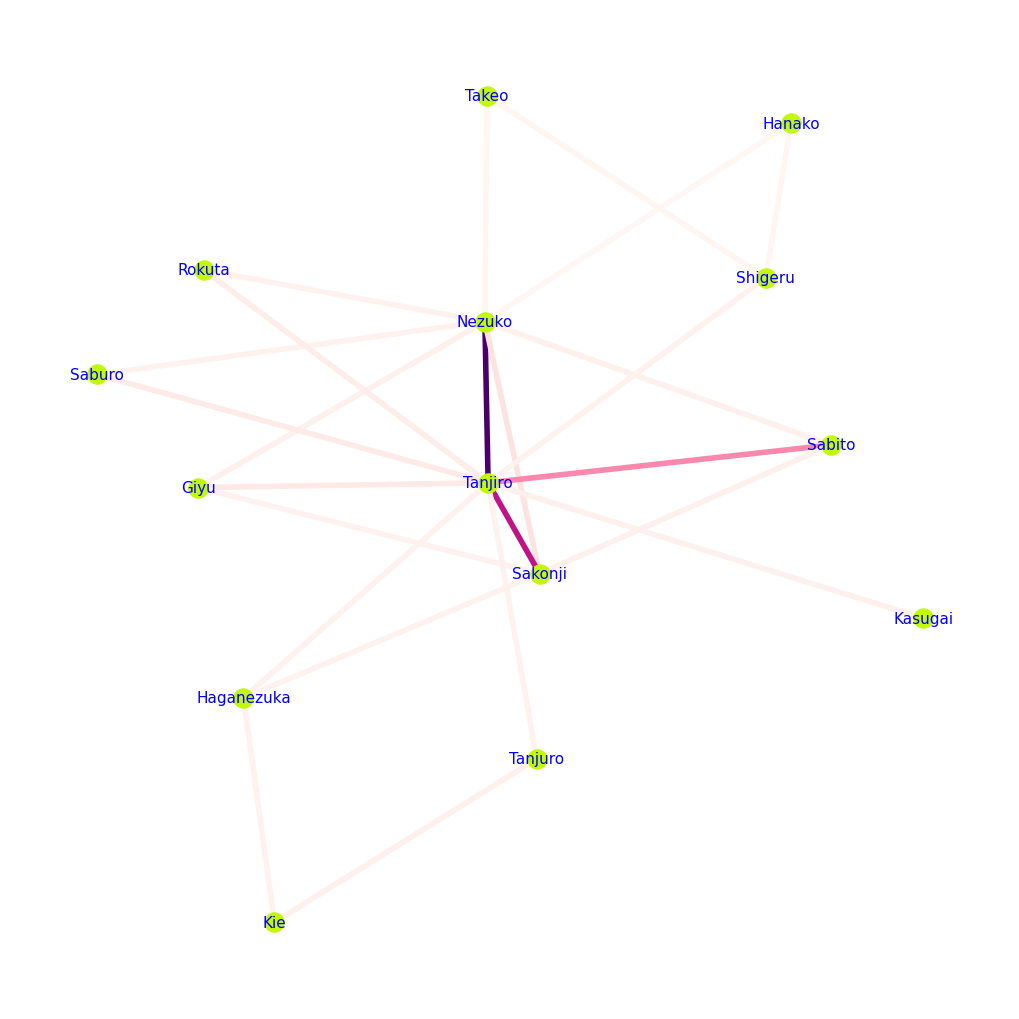

In [20]:
# https://stackoverflow.com/a/22971333
   
plt.figure(figsize=(10,10))
pos = nx.kamada_kawai_layout(G)

Weights =  nx.get_edge_attributes(G, 'value').values()

arggs = {
        'with_labels' : 'True',
        'node_size' : 200,
        'node_color' : '#C2F906',
        'edge_color' : Weights, 
        "edge_cmap": plt.cm.RdPu,
        'width' : 4,
        'font_size' : 11,
        'font_color' : 'blue'
        }

nx.draw(G, pos = pos, **arggs)
plt.show()

## 3.2 Graph visulization using [pyvis](https://pyvis.readthedocs.io/en/latest/tutorial.html#visualization) module

In [21]:
# https://pyvis.readthedocs.io/en/latest/tutorial.html#example-visualizing-a-game-of-thrones-character-network

# net = Network(notebook = True, width = '950px', height = '800px', bgcolor = '#222222', font_color = 'white')
net = Network(notebook = True, width = '1300px', height = '950px', bgcolor = 'white', font_color = 'black')
from IPython.display import IFrame
node_degree = dict(G.degree)

# Setting node size
nx.set_node_attributes(G, node_degree, 'size')

net.from_nx(G)
# net.save_graph('src/htmls/S01.html')
net.show('src/htmls/S01.html')
IFrame('src/htmls/S01.html', width=1300, height=950)

src/htmls/S01.html


# 4. Community Detection using [python-louvain](http://python-louvain.readthedocs.io/) (for sample data)

In [22]:
partition = community_louvain.best_partition(G)
nx.set_node_attributes(G, partition, 'group')

print(f"Type of 'partition' :: {type(partition)}\n\n{partition}") 

Type of 'partition' :: <class 'dict'>

{'Nezuko': 0, 'Hanako': 1, 'Shigeru': 1, 'Takeo': 1, 'Rokuta': 0, 'Tanjiro': 0, 'Saburo': 0, 'Giyu': 0, 'Sakonji': 0, 'Sabito': 0, 'Haganezuka': 2, 'Tanjuro': 2, 'Kie': 2, 'Kasugai': 0}


In [23]:
# net = Network(notebook = True, width = '950px', height = '800px', bgcolor = '#222222', font_color = 'white')
net = Network(notebook = True, width = '1000px', height = '780px', bgcolor = 'white', font_color = 'black')

net.from_nx(G, )
# net.save_graph('src/htmls/S01_Communities.html')
net.show('src/htmls/S01_Communities.html')

src/htmls/S01_Communities.html


# 5. Helper Functions for all seasons analysis

In [24]:
def generate_spacy_tokens(filename):
    
    '''
    Takes file name as input and return a spaCy NER object
    
    To see first 500 words as NER, comment out the code.
     
    Input : 
      - string : filename of the summary file
    Return :
      - spaCy NER object
    '''
    
    with open(filename, 'r', encoding='utf-8') as f:
        summary = f.read()
        
    summary = summary.replace('\n', '\n. ')
    
    summary = NER(summary)
    
    # displacy.render(summary[:500], style = 'ent', jupyter = True)
    
    return summary

In [25]:
def generate_entity_datafrane(summary):
    
    '''
    This function extracts NER entities from spaCy summary text
    and return a pandas dataframe with columns as text and list of entities.
    
    To see first 5 rows of the returning dataframe, comment out the code.
    
    Input : 
      - string : spaCy summary file
    Return :
      - pandas dataframe : entity_df
    '''
    
    entity_df = []

    for sentence in summary.sents:
        entity_lis = [ent.text for ent in sentence.ents]
        entity_df.append({'sentence' : sentence, 'entities' : entity_lis})

    entity_df = pd.DataFrame(entity_df)
    
    # display(entity_df.head().style.set_caption('entity_df').set_table_styles(styles))
    
    return entity_df

In [26]:
def clean_entity_df(df, char_df):
    
    '''
    This funtion takes entity_df and character_df as input and filters the entity_df values based on character_df.
    Extracts only character names and stores in new column of entity_df.
    A pandas dataframe is returned where there is atleast one entry in the newly created column.
    
    To see first 5 rows of the returning dataframe, comment out the code.
    
    Input : 
      - pandas dataframe : entity_df
      - pandas dataframe : character_df
    Return :
      - pandas dataframe : processed entity_df
    '''
    
    df['char_entities'] = df.entities.apply(lambda x: filter_entities(x, char_df))
    df = df[df['char_entities'].map(len) > 0]
    df.reset_index(inplace = True, drop = True)
    
    # display(df.head().style.set_caption('cleaned entity_df').set_table_styles(styles))
    
    return df

In [ ]:
def generate_relationships(df):
    
    '''
    This function takes entity_df as input and iterates through whole the rows.
    We are taking a window_size and listing all the entries in that window and stores it as 'char_list'.
    From this listed 'char_list' we generates relationship and stores it as 'relationship'.
    A pandas dataframe is generating using this 'relationship' and return.
    
    In this exapmle in 'char_list', item 5 & 6, are same. So skipping similar items like this.
    Otherwise considering 1st item as 'source' and 2nd item as 'destination'.
    
    Input : 
      - pandas dataframe : entity_df
    Return :
      - pandas dataframe : relationship_df
    '''
    
    relationship = []
    window_size  = 5
    
    for idx in range(df.shape[0]):
        e_idx = min(idx+window_size, df.shape[0])
        char_list = sum(df.loc[idx:e_idx].char_entities, [])

        # char_list = list(map(name_correction, char_list))

        unique_char = [char_list[i] for i in range(len(char_list)) if (i==0) or char_list[i] != char_list[i-1]]
        
        if len(unique_char) > 1:
            for idx, a in enumerate(unique_char[:-1]):
                b = unique_char[idx + 1]
                relationship.append({'Source' : a, 'Destination' : b})
                
    return pd.DataFrame(relationship)

In [28]:
def generate_graph_weights(df):
    
    '''
    Takes the 'relationship_df' as input and using pandas groupby funtion to count
    the number of occurance and stores in it in new coulcoulm 'value' and return the same dataframe.
    This 'value' will help us in identifying importance of the edges.
    
    To see first 5 rows of the returning dataframe, comment out the code.
    
    Input : 
      - pandas dataframe : relationship_df
    Return :
      - pandas dataframe : processed relationship_df
    '''
    
    df['value'] = 1
    df = df.groupby(['Source', 'Destination'], sort=False, as_index=False).sum()
    
    # display(df.head(10).style.set_caption('WT_relationship_df').set_table_styles(styles))
    
    return df

In [29]:
def generate_map(filename):
    
    '''
    Takes file name as input and processes functions,
        1. generate_spacy_tokens()
        2. generate_entity_datafrane()
        3. clean_entity_df()
        4. generate_relationships()
        5. generate_graph_weights()
        
    Using 'generate_graph_weights' functions creating a 'networkx' grapg object and returns it.
    
    To see first 5 rows of the 'relationship_df' dataframe, comment out the appropriate code.
    To see shape of 'relationship_df' dataframe, comment out the appropriate code.
    
    To see first 5 rows of the 'processed relationship_df' dataframe, comment out the appropriate code.
    To see shape of 'processed relationship_df' dataframe, comment out the appropriate code.
    
    Input : 
      - string : path to the summary file
    Return :
      - pandas dataframe : networkx graph object
    '''
    
    summary = generate_spacy_tokens(filename)
    
    entity_df = generate_entity_datafrane(summary)
    
    entity_df = clean_entity_df(entity_df, character_df)
    
    relationship_df = generate_relationships(entity_df)
    
    # display(relationship_df.head(10).style.set_caption('relationship_df').set_table_styles(styles))
    
    # print(f"Shape of dataset 'relationship_df' :: {relationship_df.shape}\n")
    
    relationship_df = generate_graph_weights(relationship_df)
    
    # display(relationship_df.head(10).style.set_caption('processed relationship_df').set_table_styles(styles))
    
    # print(f"Shape of dataset 'relationship_df' :: {relationship_df.shape}\n")
    
    return nx.from_pandas_edgelist(relationship_df, source = 'Source', target = 'Destination', edge_attr = 'value', create_using = nx.Graph())

In [73]:
def community_plot(graph_object, arc):
    
    '''
    This function takes a graph object and arc name as input.
    Using 'community_louvain' generates communites and using this ploting
    community network with the help of pyvis' module.
    
    Inputs :
      - networkx graph object : 
      - string : name of the arc
    Returns :
      - Saves and shows the generated pyvis community network plot
    '''
    partition = community_louvain.best_partition(graph_object)
    # You can scale degree so nodes aren't too small or huge

    nx.set_node_attributes(graph_object, partition, 'group')
    
    net = Network(notebook = True, width = '1000px', height = '700px', bgcolor = 'white', font_color = 'black')
    
    # Network physics tweaks
    net.repulsion(
        node_distance=200
    )
        #     central_gravity=0.08,
        # spring_length=220,
        # spring_strength=0.05,
    
    net.from_nx(graph_object)   

    return net.show(f'src/htmls/{arc}_Communities.html')

In [74]:
for arc in arc_order:
    if arc in map_dict:
        print(f"Generating community plot for: {arc}")
        community_plot(map_dict[arc], arc)
    else:
        print(f"Graph for '{arc}' not found in map_dict.")

community_plot(map_dict['Demon Slayer'], 'Demon Slayer')

Generating community plot for: Final Selection Arc
src/htmls/Final Selection Arc_Communities.html
Generating community plot for: Kidnapper's Bog Arc
src/htmls/Kidnapper's Bog Arc_Communities.html
Generating community plot for: Asakusa Arc
src/htmls/Asakusa Arc_Communities.html
Generating community plot for: Tsuzumi Mansion Arc
src/htmls/Tsuzumi Mansion Arc_Communities.html
Generating community plot for: Mount Natagumo Arc
src/htmls/Mount Natagumo Arc_Communities.html
Generating community plot for: Rehabilitation Training Arc
src/htmls/Rehabilitation Training Arc_Communities.html
Generating community plot for: Mugen Train Arc
src/htmls/Mugen Train Arc_Communities.html
Generating community plot for: Entertainment District Arc
src/htmls/Entertainment District Arc_Communities.html
Generating community plot for: Swordsmith Village Arc
src/htmls/Swordsmith Village Arc_Communities.html
Generating community plot for: Hashira Training Arc
src/htmls/Hashira Training Arc_Communities.html
Generati

In [32]:
# https://stackoverflow.com/a/10035974
# https://engineeringfordatascience.com/posts/matplotlib_subplots/

def plot_centrality(graph_object, season):
    
    '''
    This function takes a graph object and season name as input.
    Using different centrality measures, obtaining top 5 node characters
    and their centrality values to generate bar plot.
    
    Different Centrality measures we are using,
        1. Degree Centrality
        2. Closeness Centrality
        3. Betweenness Centrality
        4. EigenVector Centrality

    Inputs :
      - networkx graph object : 
      - string : name of the season
    Returns :
      - None : Only saves plots generated to mentioned dirctory
    '''
    
    nx_centralities = [nx.degree_centrality, nx.closeness_centrality, nx.betweenness_centrality, nx.eigenvector_centrality]
    centralities = ['Degree', 'Closeness', 'Betweenness', 'EigenVector']
    
    fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (14, 12))
    plt.subplots_adjust(hspace = 0.3)
    
    fig.suptitle(f'{season} : Character importance', y = 0.95)
    
    axs = axs.ravel()
    
    for idx, (title, nx_graph) in enumerate(zip(centralities, nx_centralities)):
        
        top_5_chars = dict(sorted(nx_graph(graph_object).items(), key = lambda x : x[1], reverse = True)[:5])
        
        sns.barplot(x = list(top_5_chars.keys()), y = list(top_5_chars.values()), ax = axs[idx])
        
        axs[idx].set_title(f'Based on : {title} centrality')
        axs[idx].tick_params(axis = 'x', labelrotation = 10)
        
    plt.savefig(f'src/plots/{season}_char_imp.svg', bbox_inches = 'tight', pad_inches = 0.3)
    
    plt.show()

# 6. Generate `networkx` graph objects for all seasons

In [33]:
# Correct story order
arc_order = [
    "Final Selection Arc",
    "Kidnapper's Bog Arc",
    "Asakusa Arc",
    "Tsuzumi Mansion Arc",
    "Mount Natagumo Arc",
    "Rehabilitation Training Arc",
    "Mugen Train Arc",
    "Entertainment District Arc",
    "Swordsmith Village Arc",
    "Hashira Training Arc",
    "Infinity Castle Arc",
    "Sunrise Countdown Arc"
]

# Load all arc files
all_summaries = glob.glob('../webscraping/data/summaries/*.txt')
arc_files = {os.path.splitext(os.path.basename(f))[0]: f for f in all_summaries}

# Reorder
summaries = [arc_files[arc] for arc in arc_order if arc in arc_files]

print(summaries)

['../webscraping/data/summaries\\Final Selection Arc.txt', "../webscraping/data/summaries\\Kidnapper's Bog Arc.txt", '../webscraping/data/summaries\\Asakusa Arc.txt', '../webscraping/data/summaries\\Tsuzumi Mansion Arc.txt', '../webscraping/data/summaries\\Mount Natagumo Arc.txt', '../webscraping/data/summaries\\Rehabilitation Training Arc.txt', '../webscraping/data/summaries\\Mugen Train Arc.txt', '../webscraping/data/summaries\\Entertainment District Arc.txt', '../webscraping/data/summaries\\Swordsmith Village Arc.txt', '../webscraping/data/summaries\\Hashira Training Arc.txt', '../webscraping/data/summaries\\Infinity Castle Arc.txt', '../webscraping/data/summaries\\Sunrise Countdown Arc.txt']


In [34]:
# For stylizing dataframes

styles = [dict(selector='caption', props=[('text-align', 'center'), ('font-size', '150%'), ('color', '#FFFFFF'), ('background-color' , '#6DA3C7')])] 

In [35]:
# Generating networkx's graph objects for all the summaries present

map_dict = {}

for arc in summaries:
    # Get filename without extension
    key = os.path.splitext(os.path.basename(arc))[0]
    print(key)  # Debug
    map_dict[key] = generate_map(arc)

map_dict


Final Selection Arc
Kidnapper's Bog Arc
Asakusa Arc
Tsuzumi Mansion Arc
Mount Natagumo Arc
Rehabilitation Training Arc
Mugen Train Arc
Entertainment District Arc
Swordsmith Village Arc
Hashira Training Arc
Infinity Castle Arc
Sunrise Countdown Arc


{'Final Selection Arc': <networkx.classes.graph.Graph at 0x20006668d60>,
 "Kidnapper's Bog Arc": <networkx.classes.graph.Graph at 0x20063c3e570>,
 'Asakusa Arc': <networkx.classes.graph.Graph at 0x200628f49e0>,
 'Tsuzumi Mansion Arc': <networkx.classes.graph.Graph at 0x20065cd5260>,
 'Mount Natagumo Arc': <networkx.classes.graph.Graph at 0x20063c4f050>,
 'Rehabilitation Training Arc': <networkx.classes.graph.Graph at 0x20063c4db50>,
 'Mugen Train Arc': <networkx.classes.graph.Graph at 0x2006773c7d0>,
 'Entertainment District Arc': <networkx.classes.graph.Graph at 0x2006773e210>,
 'Swordsmith Village Arc': <networkx.classes.graph.Graph at 0x20063c01630>,
 'Hashira Training Arc': <networkx.classes.graph.Graph at 0x20065d08670>,
 'Infinity Castle Arc': <networkx.classes.graph.Graph at 0x200661b61a0>,
 'Sunrise Countdown Arc': <networkx.classes.graph.Graph at 0x20063ad2e10>}

# 8. **Season 1**  : Finding communities and important characters

In [36]:
for arc in arc_order:
    if arc in map_dict:
        print(f"Generating community plot for: {arc}")
        community_plot(map_dict[arc], arc)
    else:
        print(f"Graph for '{arc}' not found in map_dict.")

Generating community plot for: Final Selection Arc
src/htmls/Final Selection Arc_Communities.html
Generating community plot for: Kidnapper's Bog Arc
src/htmls/Kidnapper's Bog Arc_Communities.html
Generating community plot for: Asakusa Arc
src/htmls/Asakusa Arc_Communities.html
Generating community plot for: Tsuzumi Mansion Arc
src/htmls/Tsuzumi Mansion Arc_Communities.html
Generating community plot for: Mount Natagumo Arc
src/htmls/Mount Natagumo Arc_Communities.html
Generating community plot for: Rehabilitation Training Arc
src/htmls/Rehabilitation Training Arc_Communities.html
Generating community plot for: Mugen Train Arc
src/htmls/Mugen Train Arc_Communities.html
Generating community plot for: Entertainment District Arc
src/htmls/Entertainment District Arc_Communities.html
Generating community plot for: Swordsmith Village Arc
src/htmls/Swordsmith Village Arc_Communities.html
Generating community plot for: Hashira Training Arc
src/htmls/Hashira Training Arc_Communities.html
Generati

Generating community plot for: Final Selection Arc


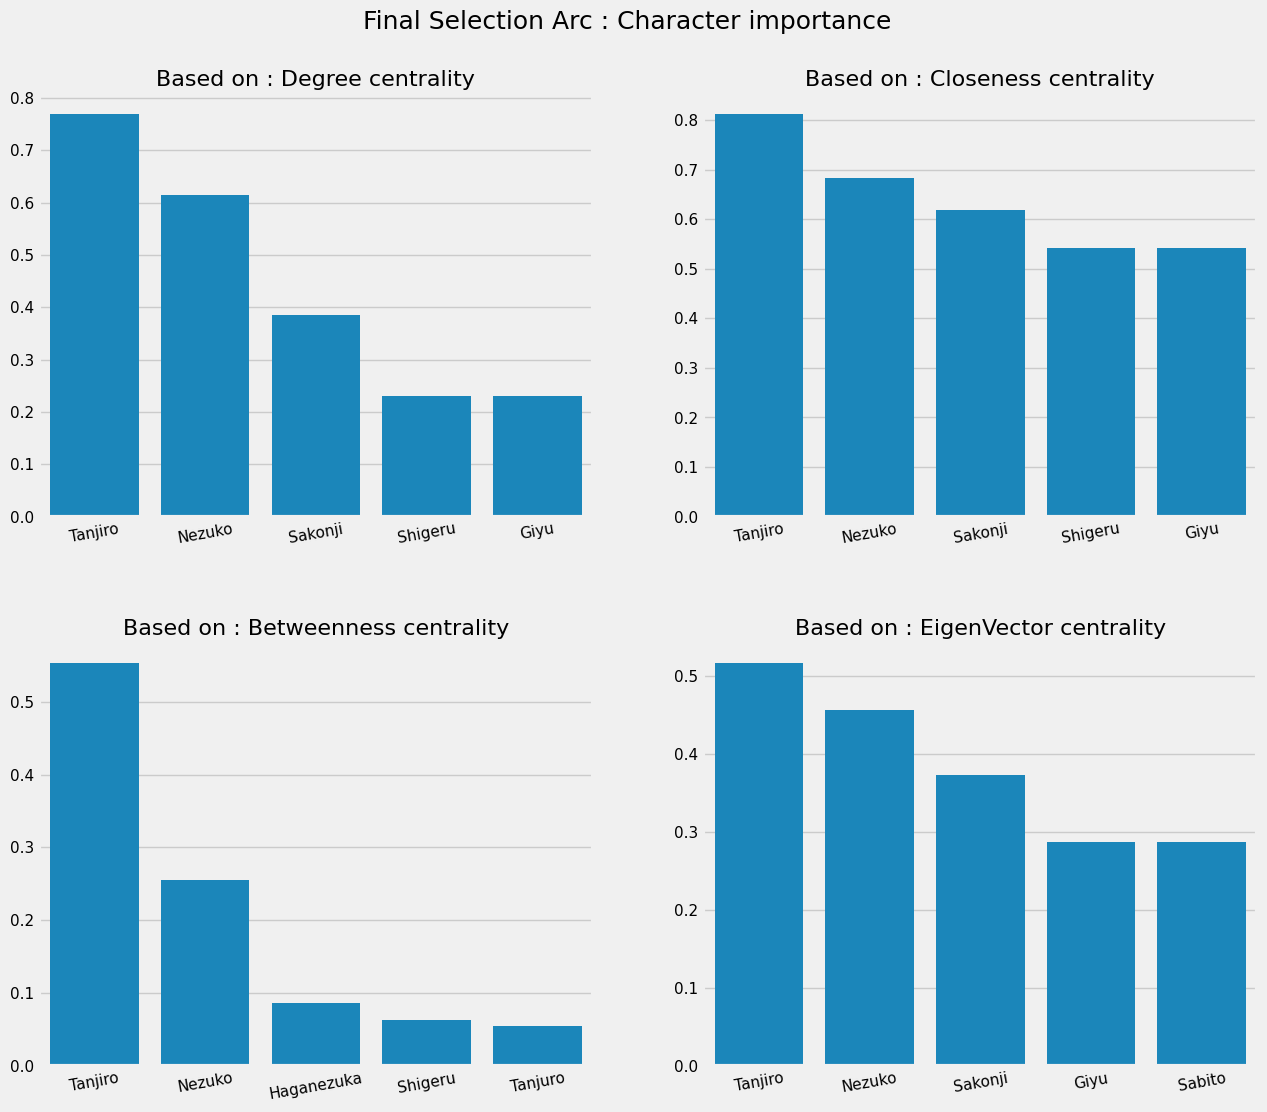

Generating community plot for: Kidnapper's Bog Arc


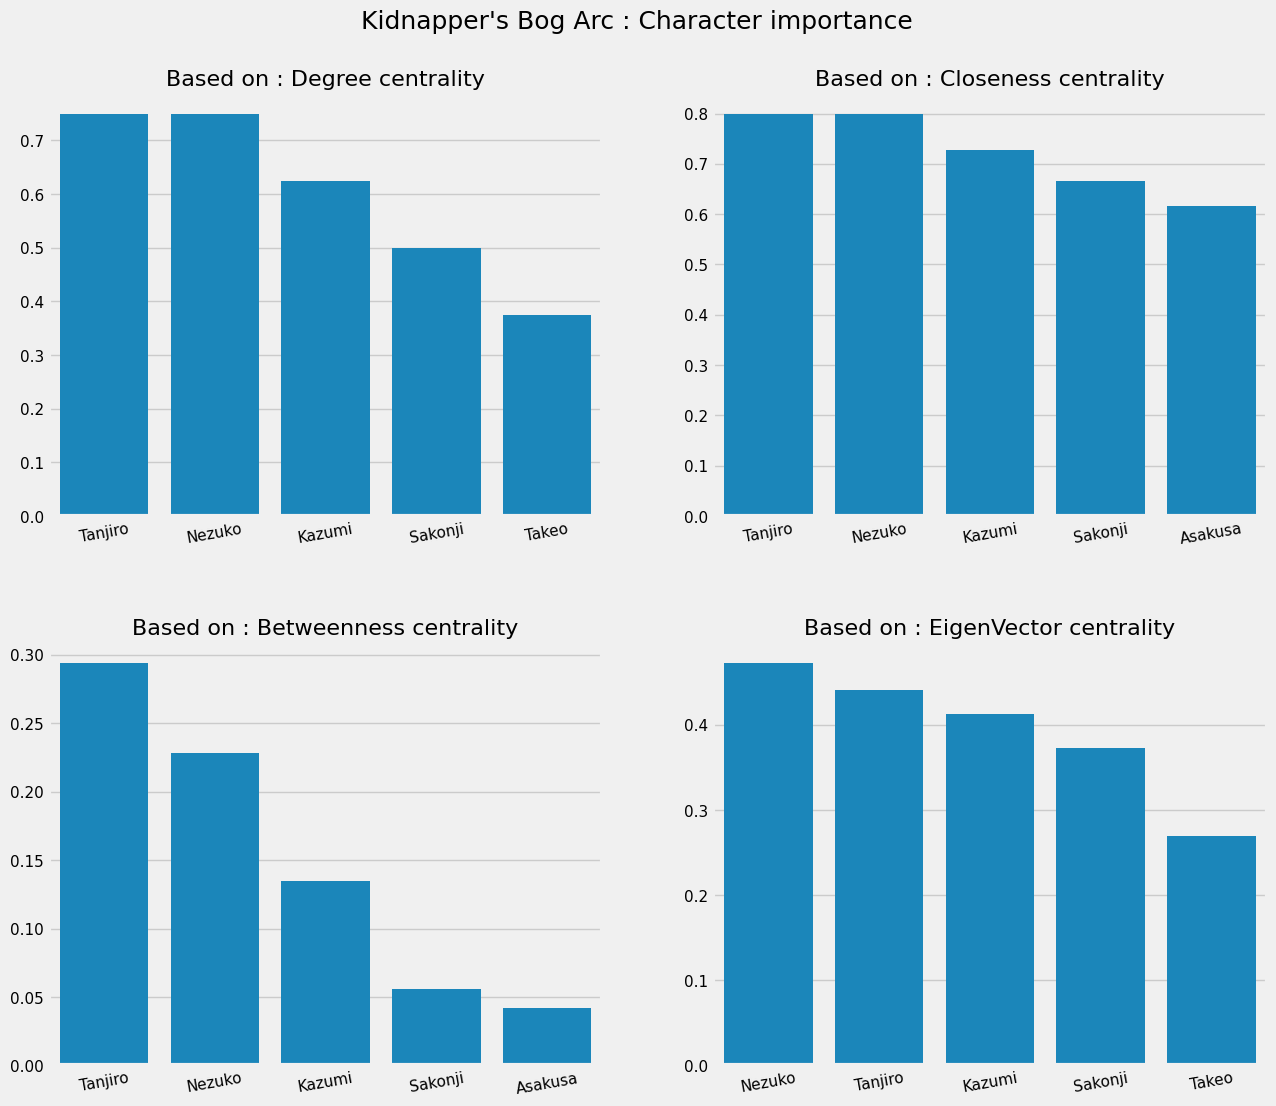

Generating community plot for: Asakusa Arc


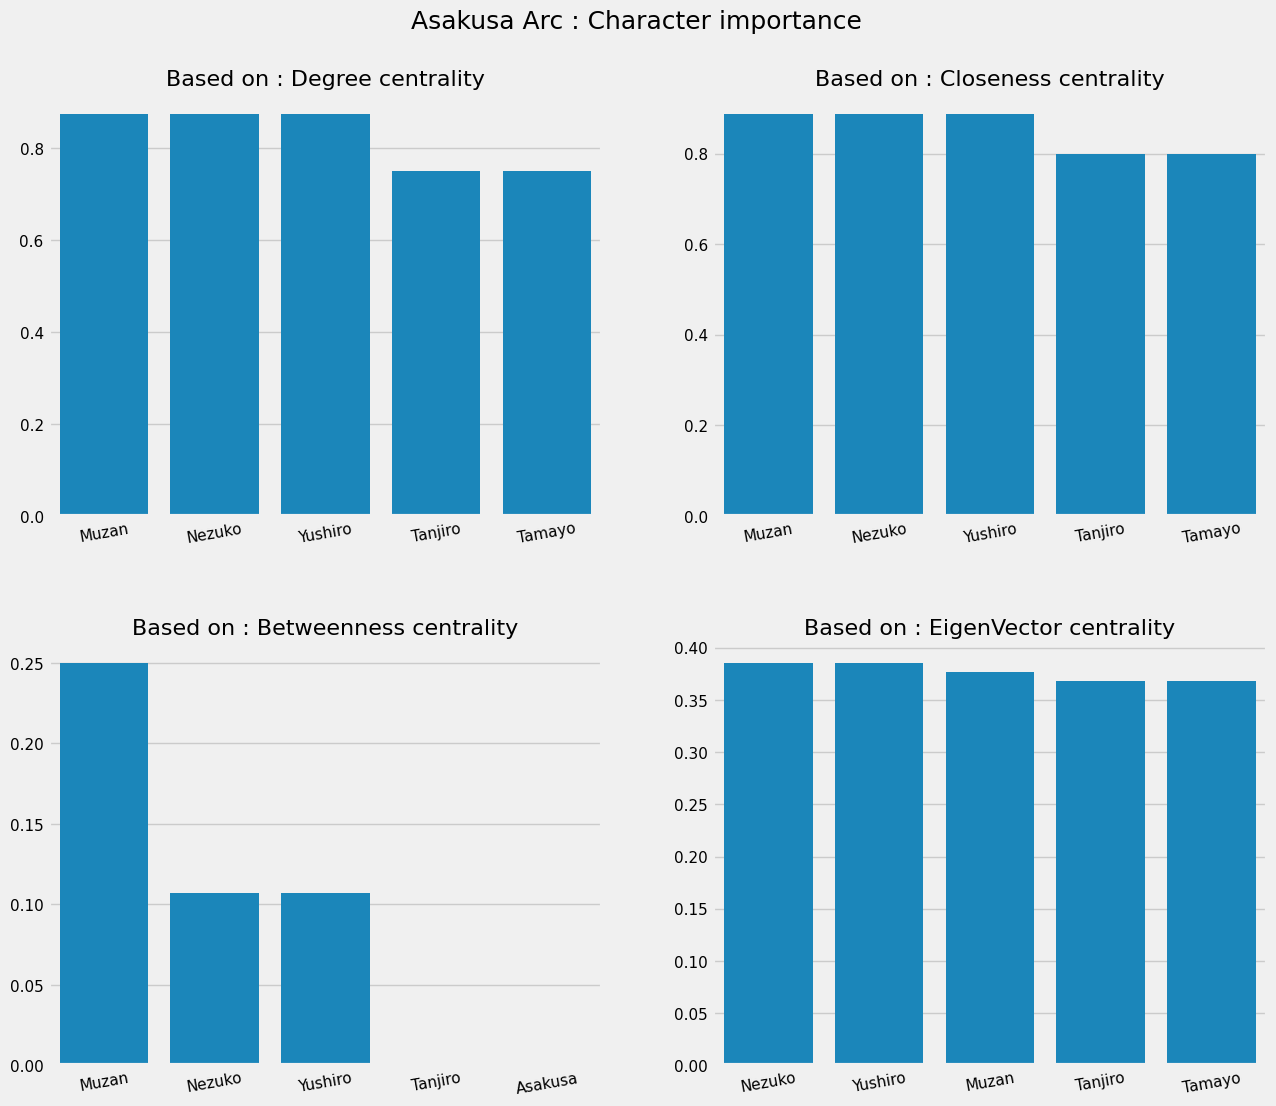

Generating community plot for: Tsuzumi Mansion Arc


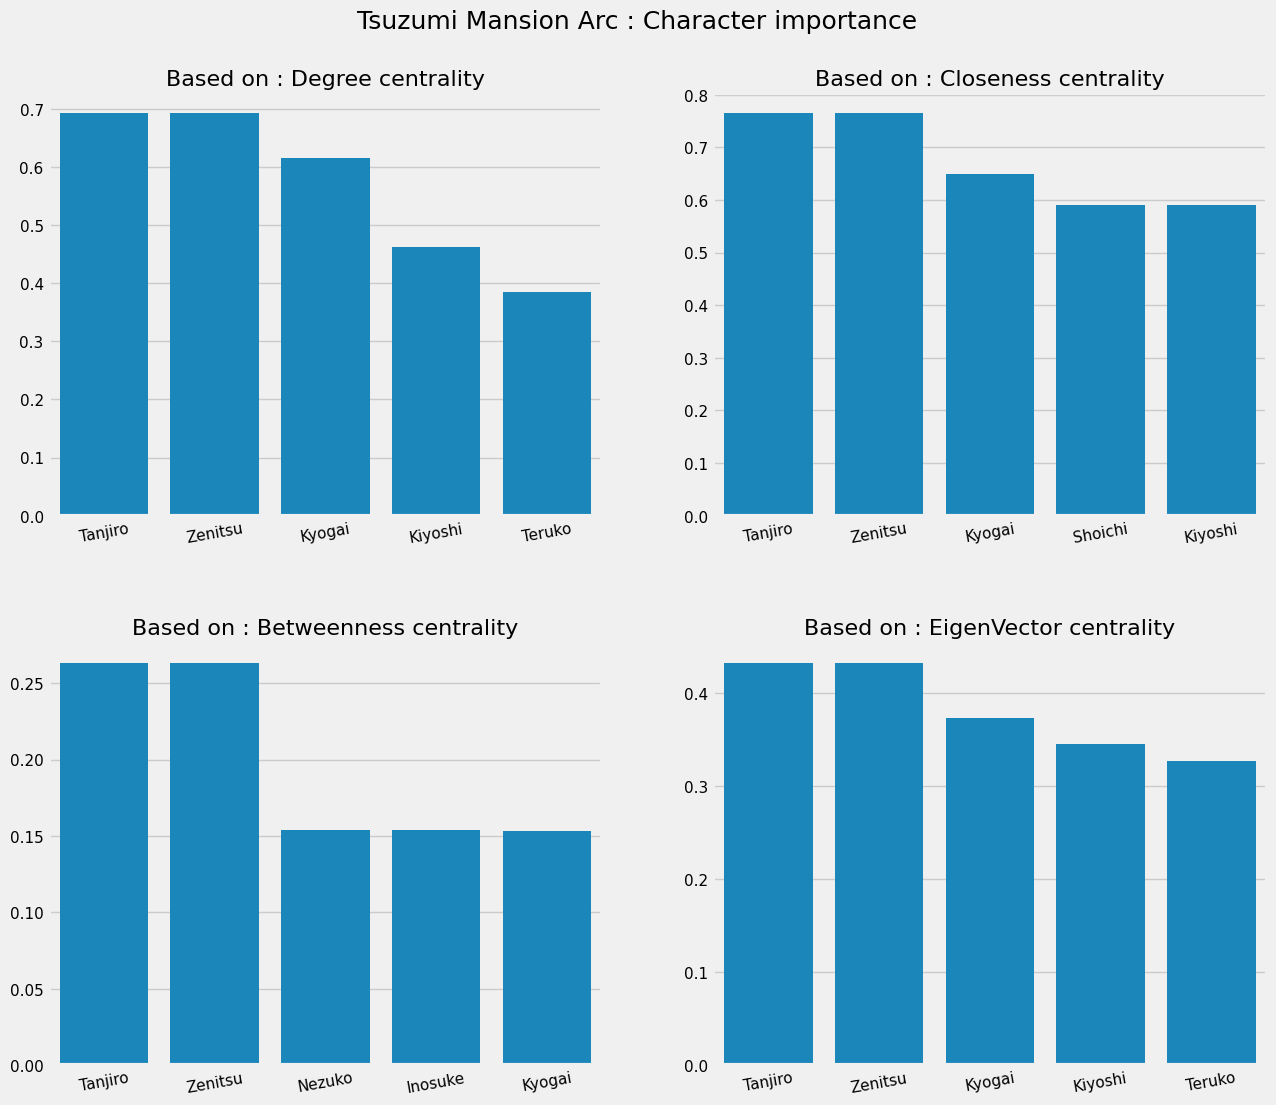

Generating community plot for: Mount Natagumo Arc


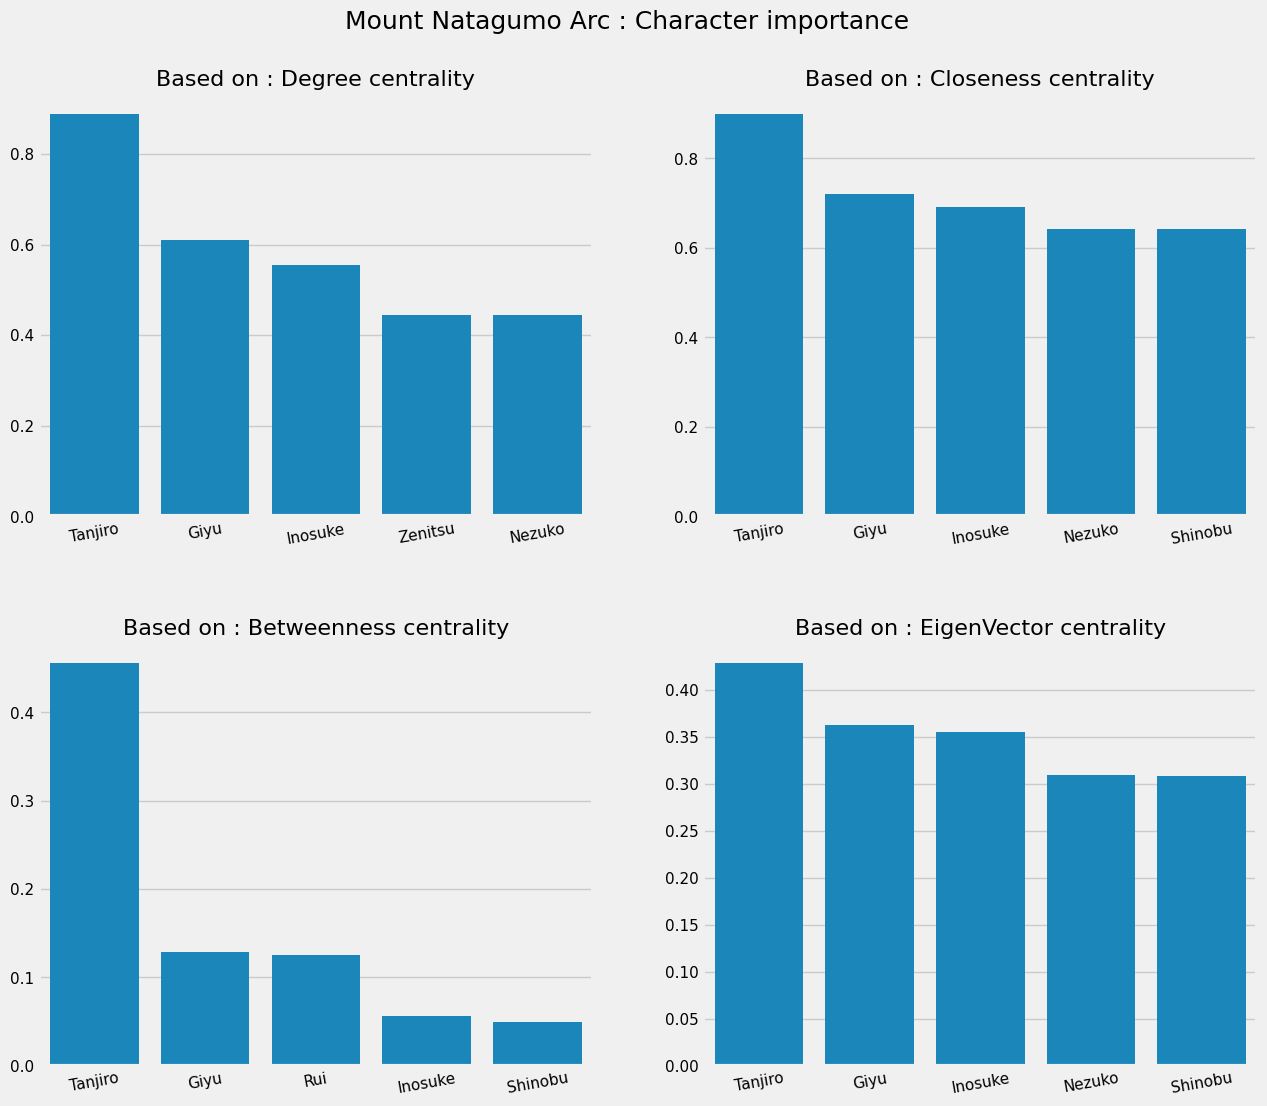

Generating community plot for: Rehabilitation Training Arc


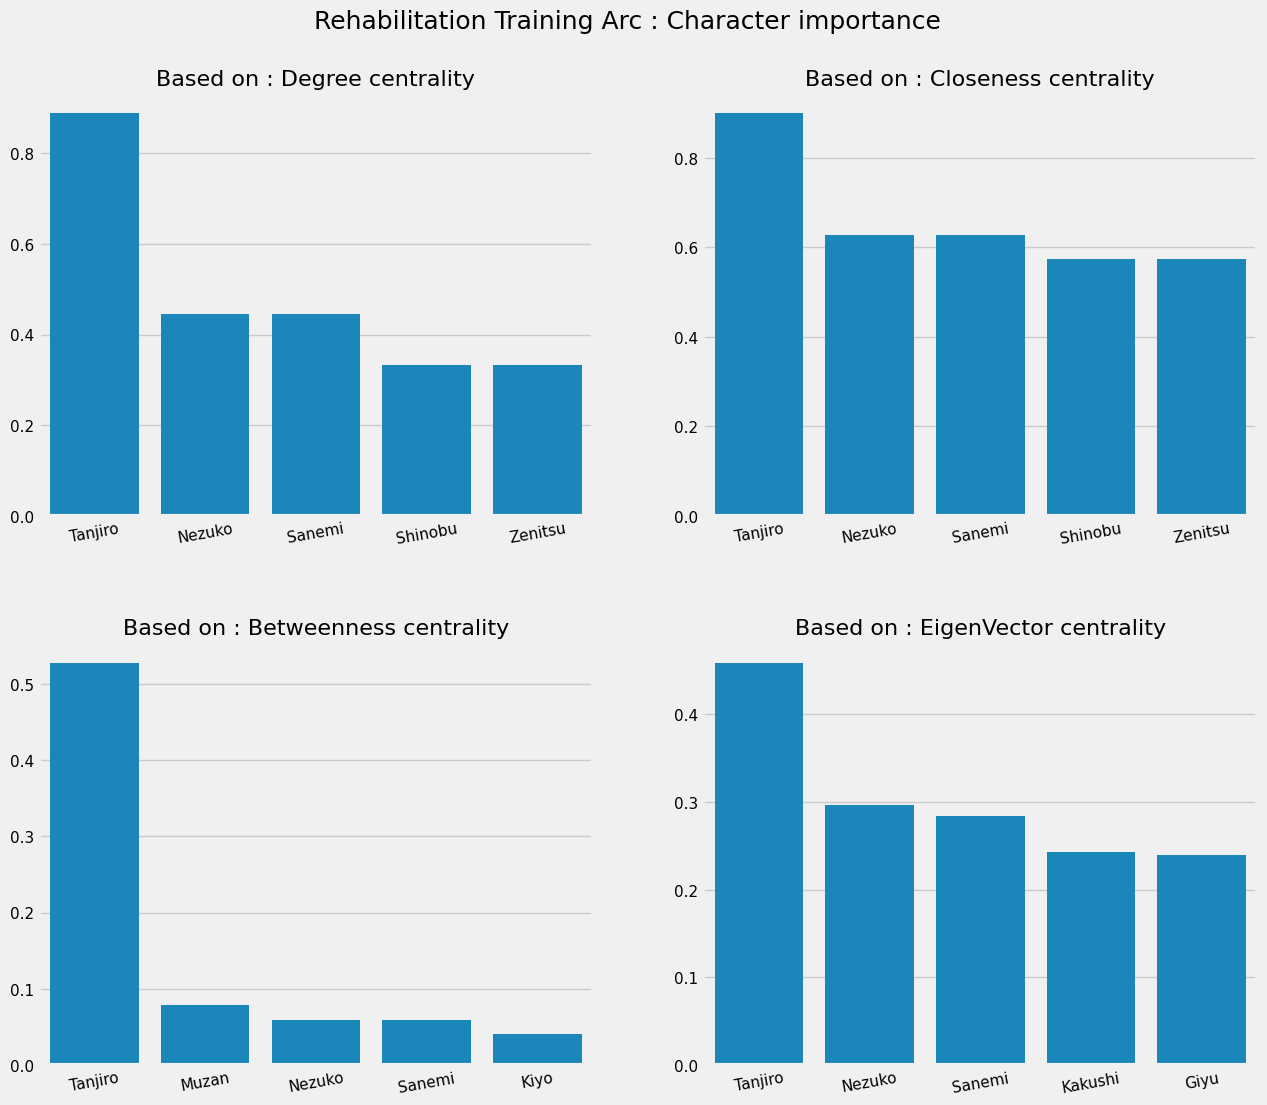

Generating community plot for: Mugen Train Arc


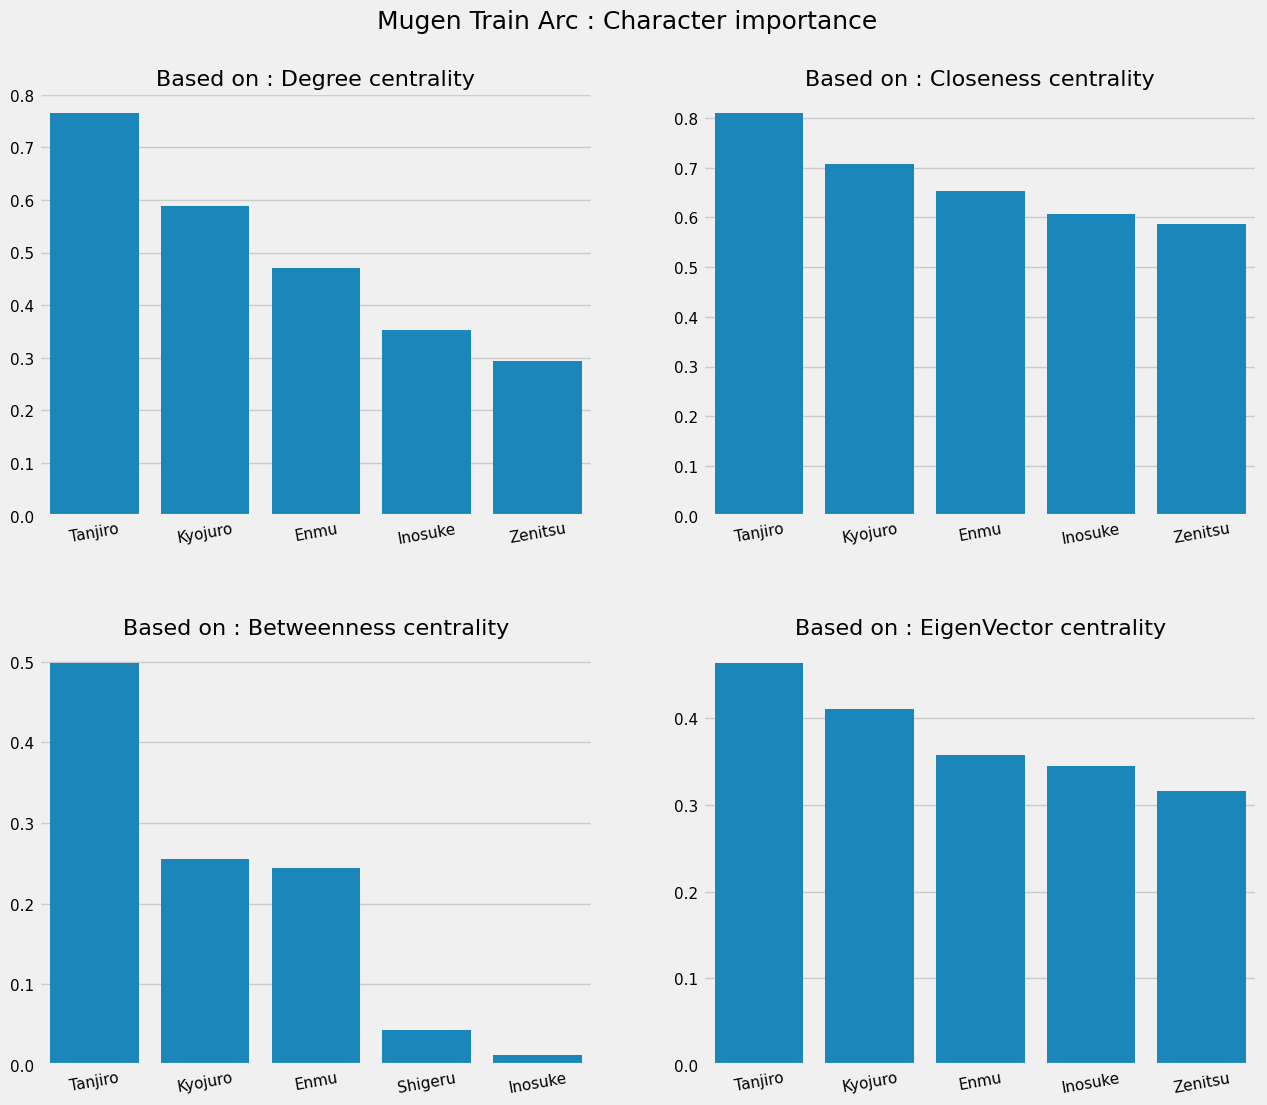

Generating community plot for: Entertainment District Arc


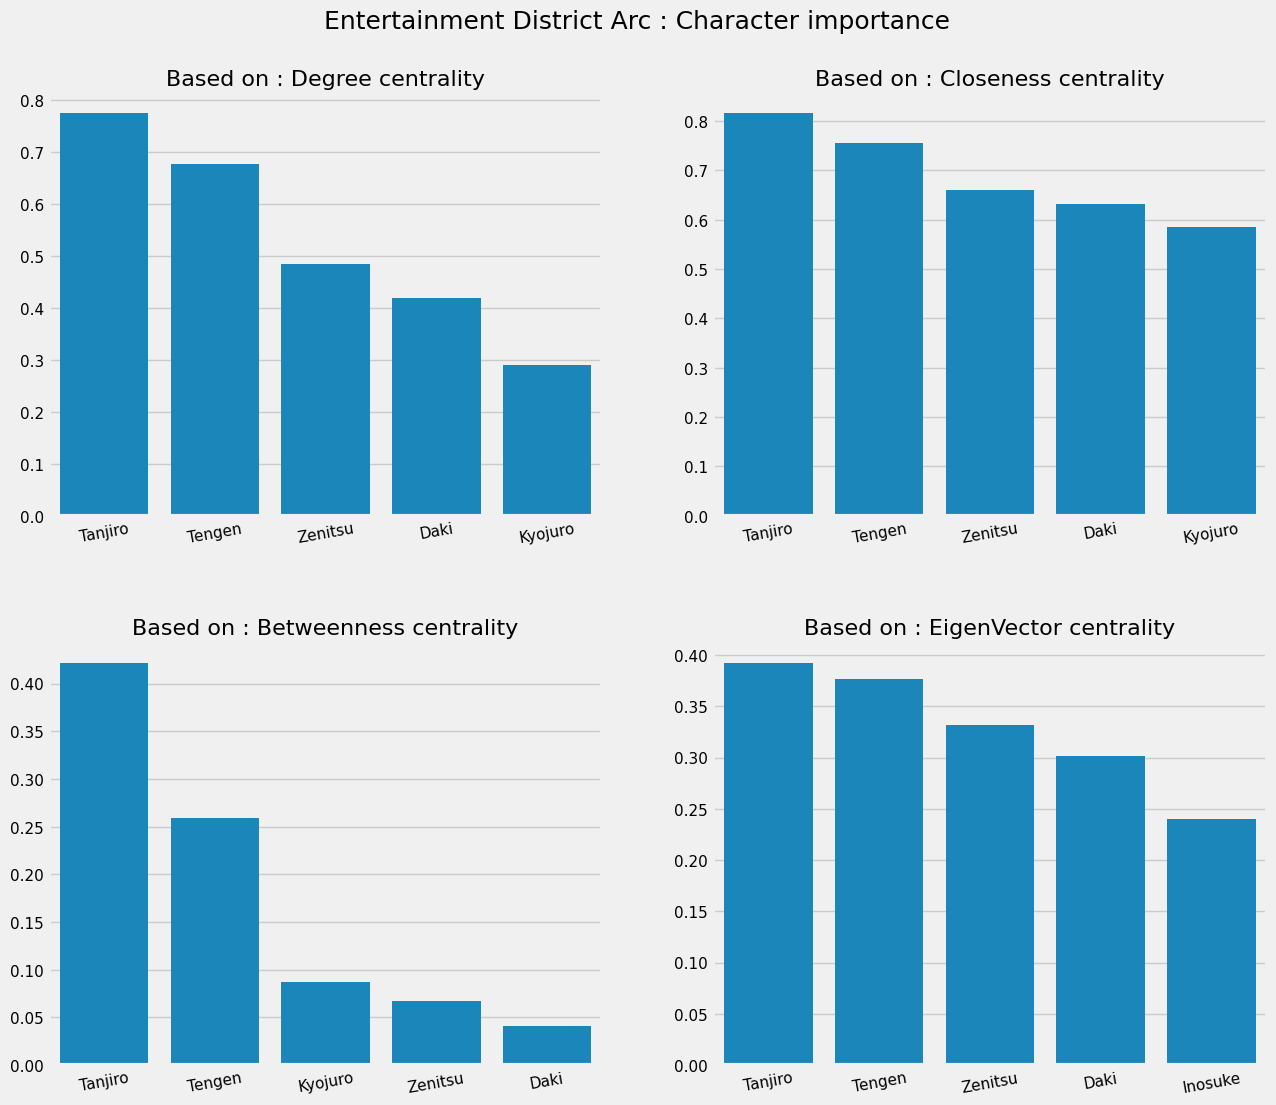

Generating community plot for: Swordsmith Village Arc


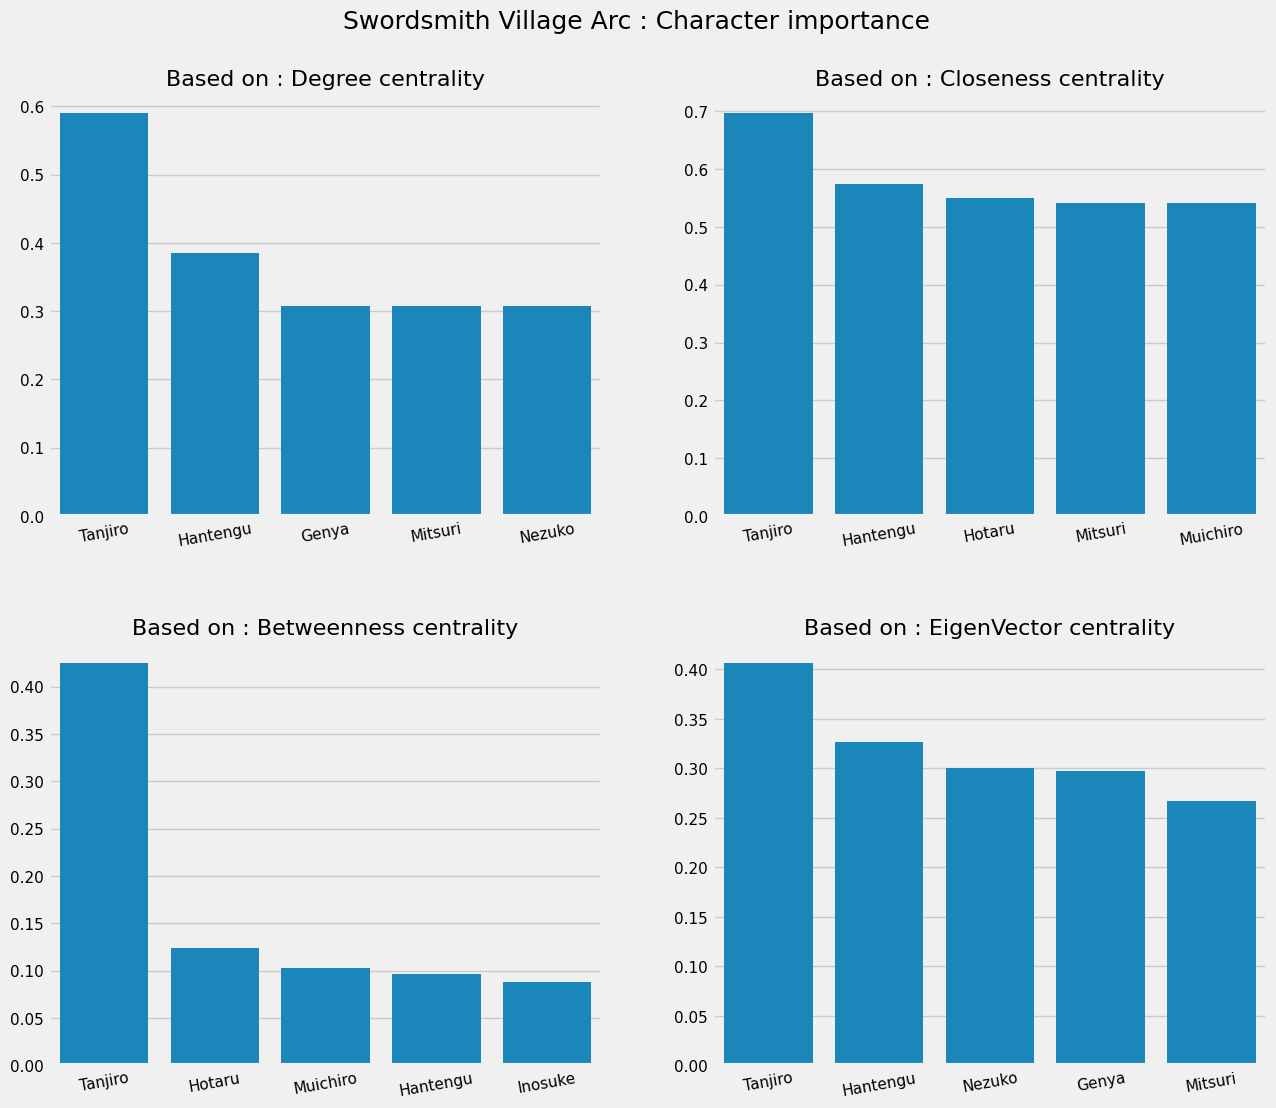

Generating community plot for: Hashira Training Arc


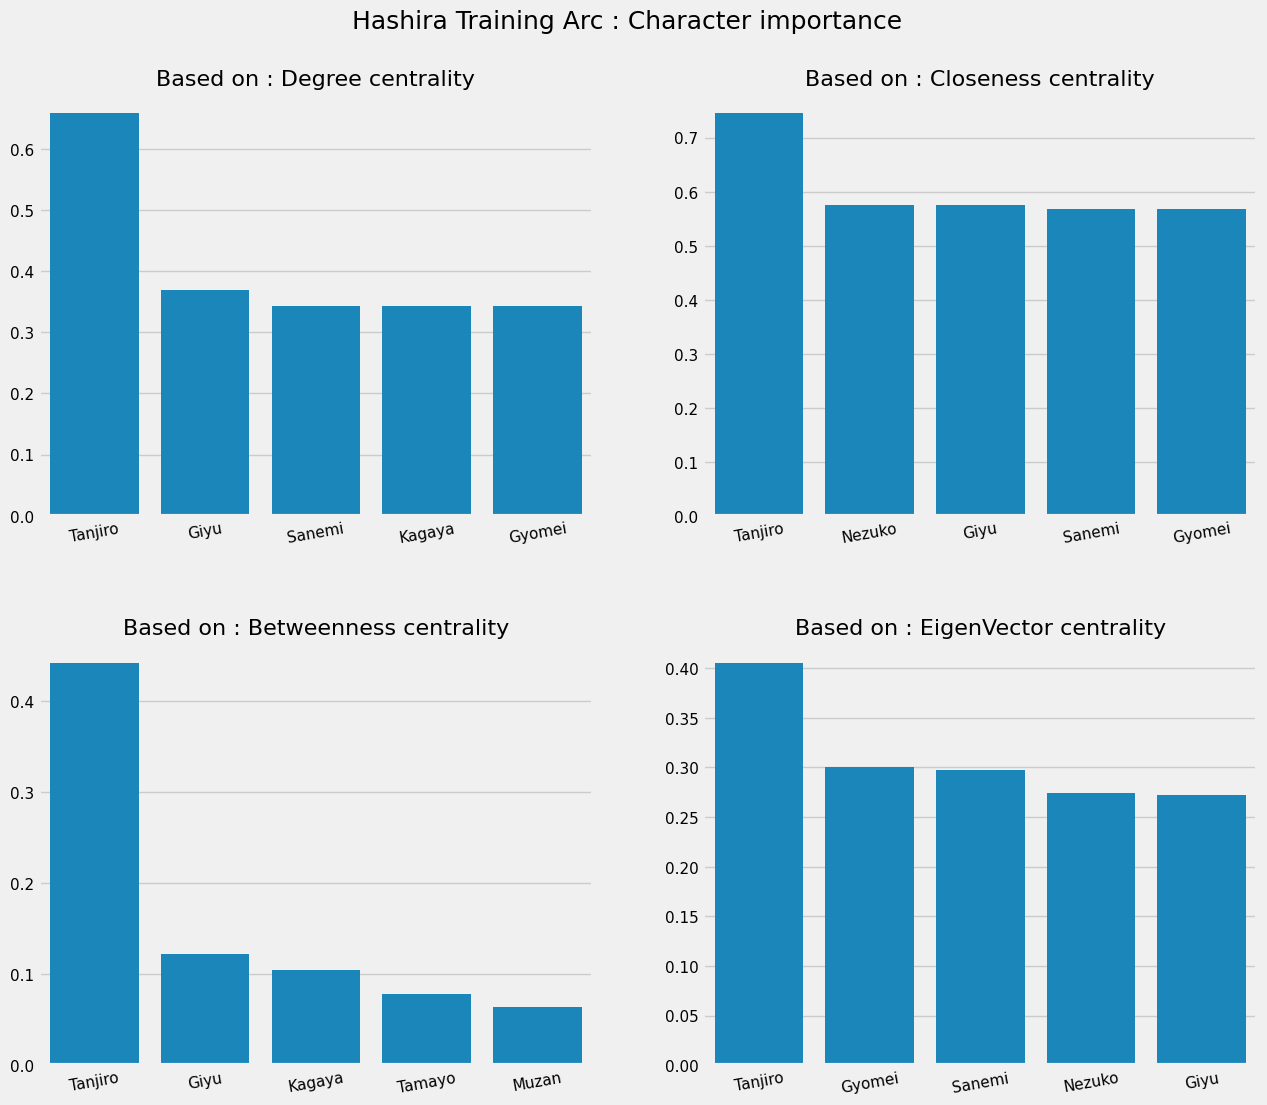

Generating community plot for: Infinity Castle Arc


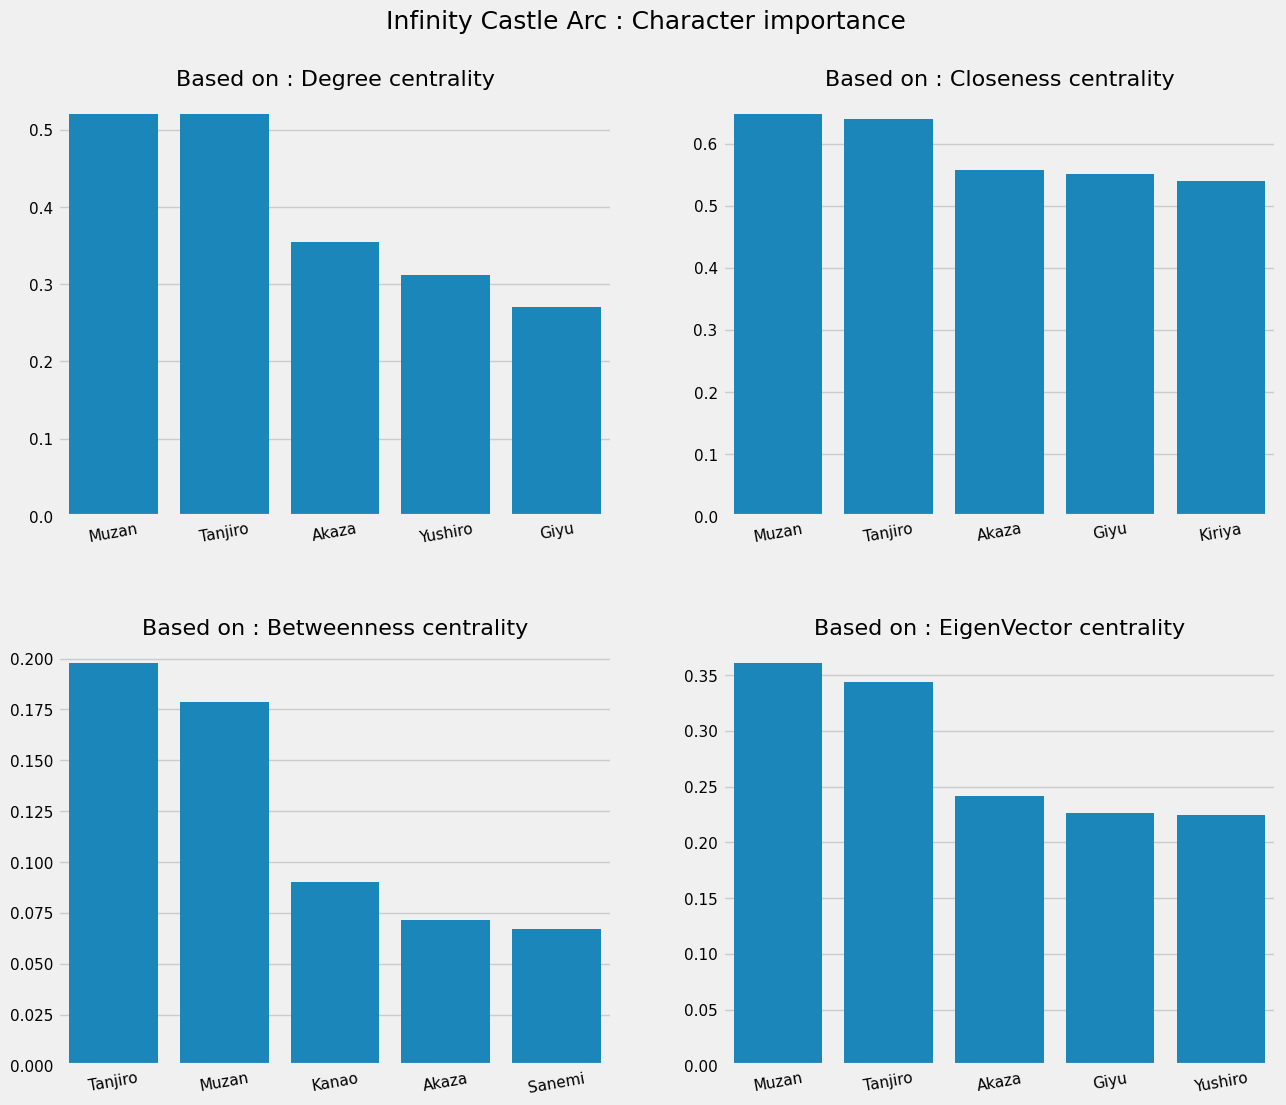

Generating community plot for: Sunrise Countdown Arc


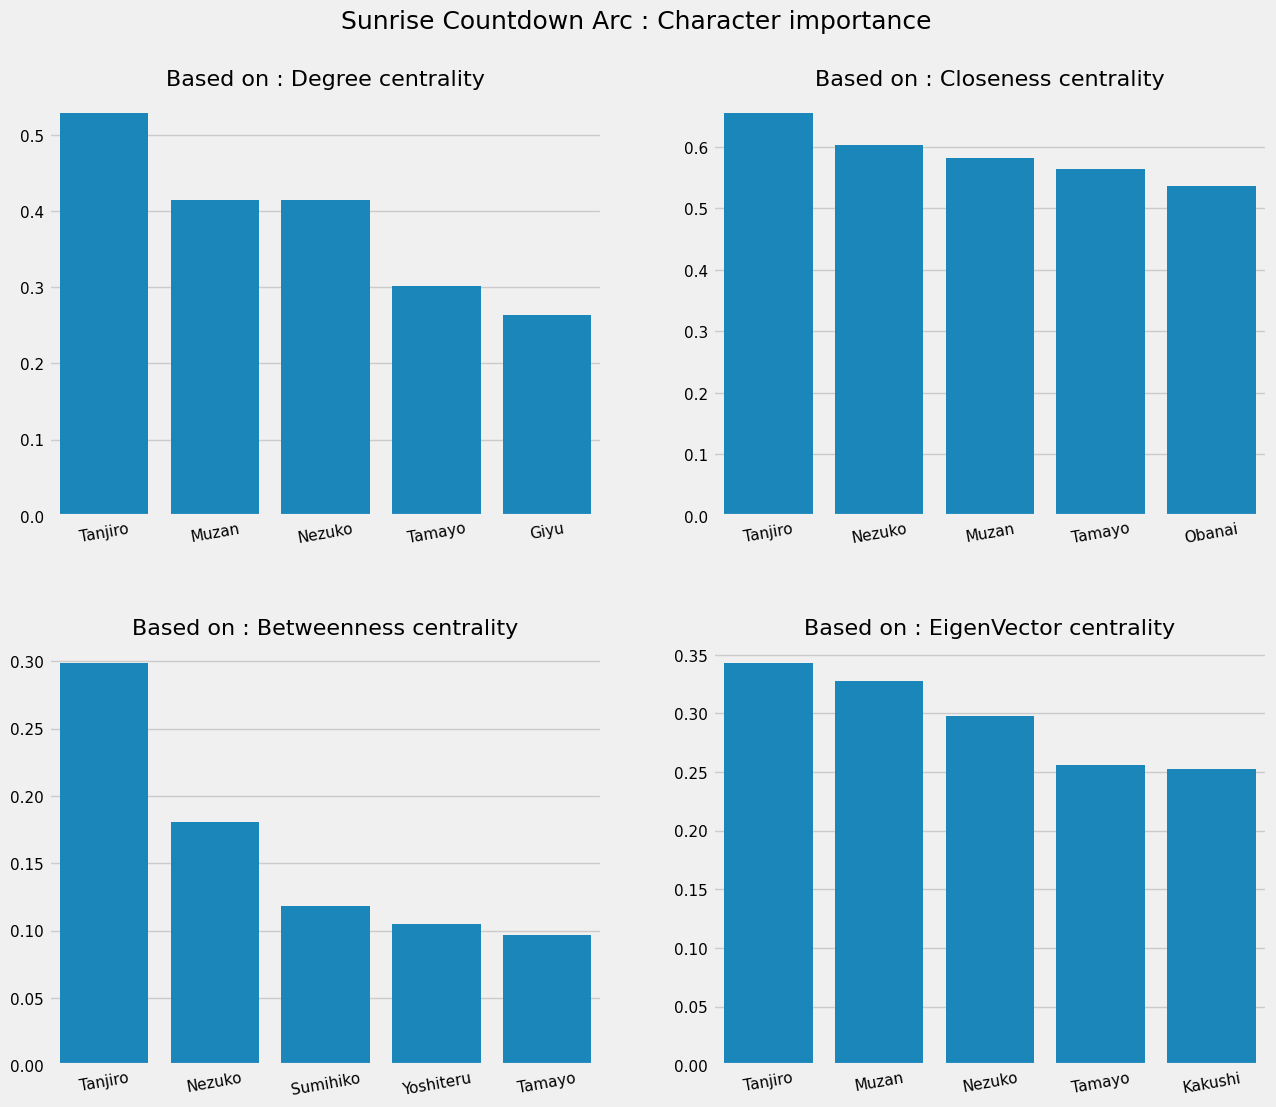

In [37]:
for arc in arc_order:
    if arc in map_dict:
        print(f"Generating community plot for: {arc}")
        plot_centrality(map_dict[arc], arc)
    else:
        print(f"Graph for '{arc}' not found in map_dict.")

# 14. **Whole series**  : Finding communities and important characters

In [38]:
# Combining all the season wise summaries to one file

combined_summary_path = 'data/summaries/combined_summaries.txt'

with open(combined_summary_path, 'w', encoding='utf-8') as combined:
    for arc in summaries:
        with open(arc, 'r', encoding='utf-8') as summary:
            combined.write(summary.read() + "\n")

In [39]:
# Generating graph object for combined text data file

combined_map = generate_map(combined_summary_path)

In [40]:
community_plot(combined_map, 'Demon Slayer')

src/htmls/Demon Slayer_Communities.html


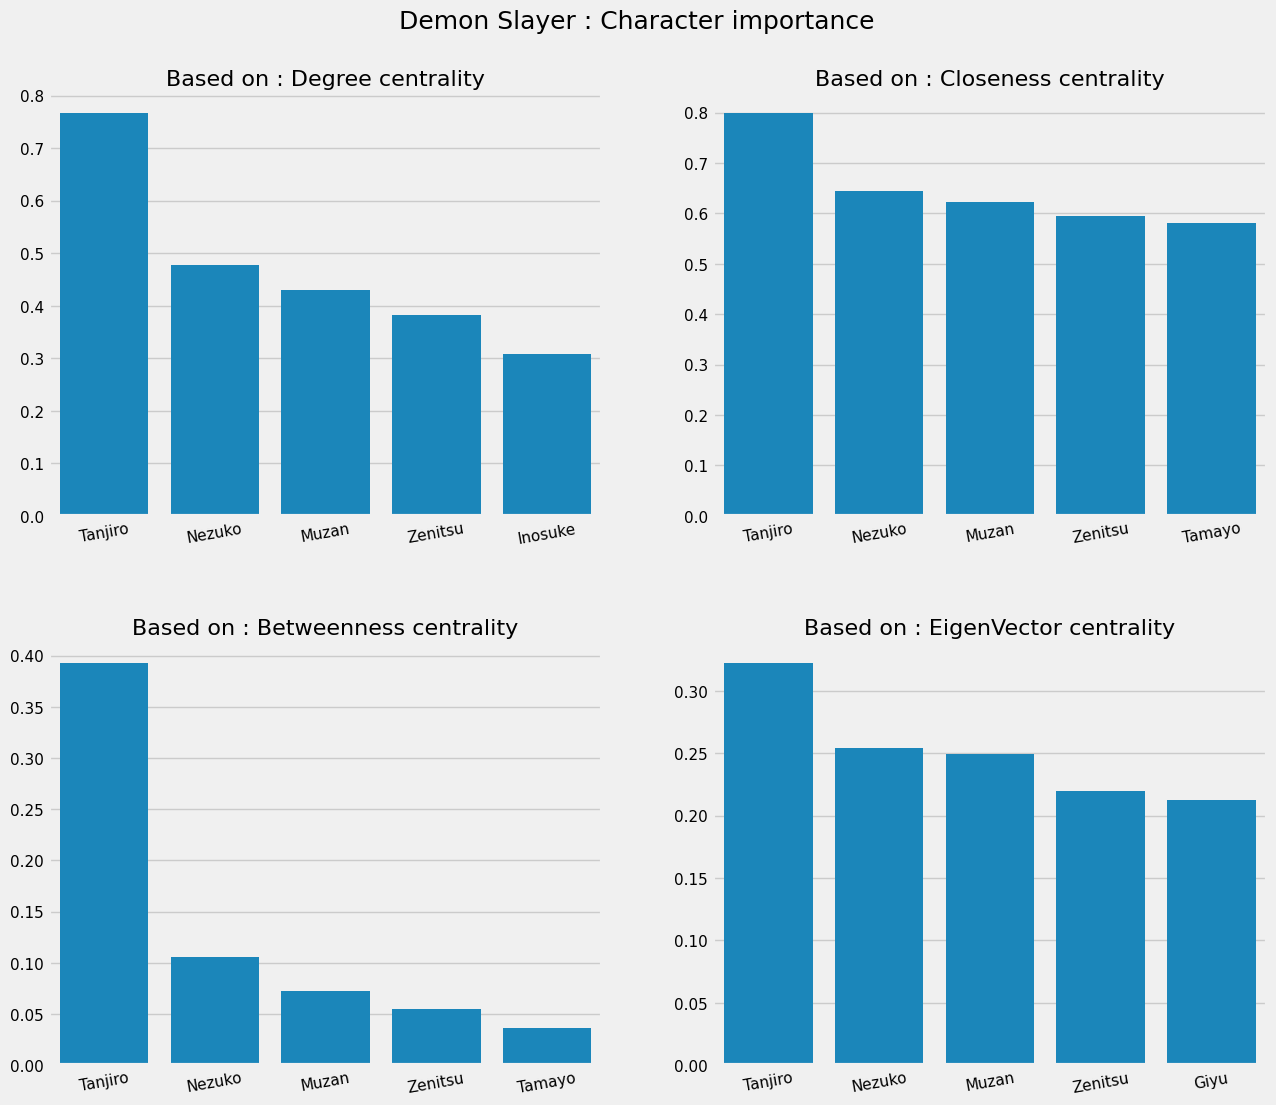

In [41]:
plot_centrality(combined_map, 'Demon Slayer')

# 15. Evolution of importance of characters over the series

In [42]:
# https://plotly.com/python/static-image-export/

def character_Importence(centrality, title_):
    
    '''
    Takes networkx centrality object function and a string for plot title.
    Iterated through all the arcs networkx_graph object and generates centrality score, 
    on this takes top 5 node characters with the centrality scores.
    Using this record of 5 top nodes of each season ploting a line plot using 'Plotly' module.
    
    Input :
      - networkx centrality object : centrality
      - sting : title_
    Return :
      - None : Only plots the lineplot and saves it to the metioned directory.
    '''
    
    set_of_char = set()
    file_name = 'src/char_imp/' + title_ + '.svg'
    title_ = ' '.join(title_.split('_')).title()
    
    if title_ != 'betweenness_centrality' :
        evolution = [centrality(map_) for arc, map_ in map_dict.items()]
    else:
        evolution = [centrality(map_, weight = 'value') for arc, map_ in map_dict.items()]
    evolution_df  = pd.DataFrame(evolution)
    evolution_df.index = list(map_dict.keys())
    
    for idx in range(evolution_df.shape[0]):
        
         set_of_char.update(evolution_df.iloc[idx].sort_values(ascending = False)[:5].index) 
            
    set_of_char = list(set_of_char)

    evolution_df = pd.melt(evolution_df[set_of_char].reset_index().fillna(0), id_vars = 'index', var_name = 'Char_Name', value_name = 'Centrality_Score')
    
    # fig = px.line(evolution_df, x = 'index', y = 'Centrality_Score', color = 'Char_Name', height = 500, width = 1000, labels = {'Centrality_Score' : f'{title_} Score', 'index' : ''})
    # fig.update_layout(
    #     {'title' : 
    #          {'text' : f'Character Importance : {title_}', 'x' : 0.5},
    #      'hovermode' : 'x'
    #      # 'hovermode' : 'x unified' # For different style hover data information
    #     })
    # fig.update_traces(
    #     {'mode' : 'markers + lines',
    #      'hovertemplate' : None
    #     })
    
    # fig.write_image(file_name)
    # fig.show()
    # Pivot data for heatmap
    heatmap_df = evolution_df.pivot(index='Char_Name', columns='index', values='Centrality_Score').fillna(0)
    # Reorder columns according to arc_order
    heatmap_df = heatmap_df[arc_order]
    fig = px.imshow(
        heatmap_df,
        labels=dict(x="Demon Slayer", y="Characters", color=f"{title_} Score"),
        x=heatmap_df.columns,
        y=heatmap_df.index,
        aspect="auto",
        color_continuous_scale='Reds'
    )
    fig.update_layout(title_text=f'Character Importance Heatmap: {title_}', title_x=0.5)
    fig.write_html(f'src/char_imp/{title_}_heatmap.html')

In [43]:
character_Importence(nx.closeness_centrality, 'closeness_centrality')
character_Importence(nx.betweenness_centrality, 'betweenness_centrality')
character_Importence(nx.eigenvector_centrality, 'eigenvector_centrality')
character_Importence(nx.pagerank, 'pagerank')

# 17. Correlation between different measures

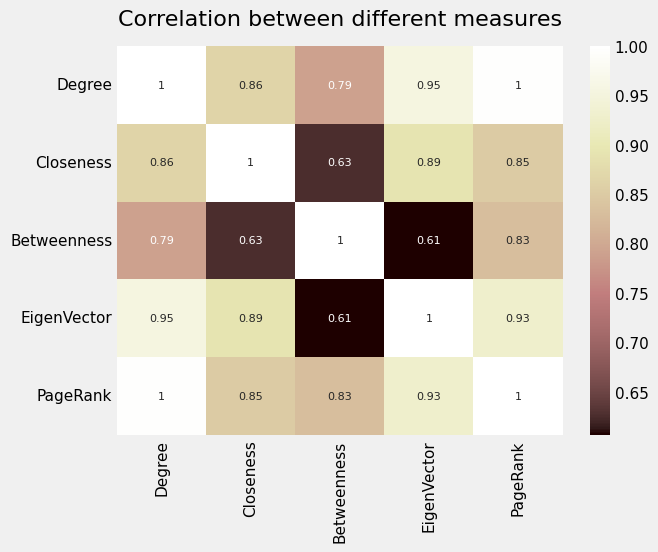

In [44]:
# https://stackoverflow.com/a/56243909

all_measures = [nx.degree_centrality(combined_map), nx.closeness_centrality(combined_map), nx.betweenness_centrality(combined_map, weight='weight'), nx.eigenvector_centrality(combined_map), nx.pagerank(combined_map)]
idx_name = ['Degree', 'Closeness', 'Betweenness', 'EigenVector', 'PageRank']

cor = pd.DataFrame(all_measures)
cor.index = idx_name
sns.heatmap(cor.T.corr(), annot = True, annot_kws = {'size' : 8}, cmap = plt.get_cmap('pink')) # pink, afmhot
plt.title('Correlation between different measures', pad = 15)
plt.show()

- This shows **PageRank** and **Degree** aare highly correlated or they are similar.
- **Betweenness** and **Closeness** are the lowest correlated one present, but still have a correlatoin on 0.74.

# 18. Exporting edge list for [Gephi](https://gephi.org/) network visualization

In [45]:
def csv_for_gephi(graph_obj, name_):
    
    '''
    Gephi is a open-source network visualization tool. To work with Gephi, we can use CSV files.
    Using networkx's 'to_pandas_edgelist' funtion we can extract all the present graph graph infromations.
    Combining this with 'graph's' node data we will have enough data for our Gephi needs.
    
    Input :
      - networkx graph object :graph_obj
      - string : name_
    Return :
      - None : Only saves CSV files at it's desired loactions
    '''
    
    edge_list_df = nx.to_pandas_edgelist(graph_obj).rename(columns = {'value' : 'weight'}).drop('width', axis = 1)
    node_df = pd.DataFrame(dict(graph_obj.nodes)).T.reset_index().rename(columns = {'index' : 'source'}).drop('size', axis = 1)
    final_df = pd.merge(edge_list_df, node_df, on = 'source').rename(columns = {'group' : 'community'})
    final_df.to_csv(f'data/gephi_files/{name_}.csv', index = False)

In [46]:
# Adding 'combined_map' object to map_dict dictionary and generaing CSV's for Gephi

map_dict['Demon Slayer'] = combined_map

for arc, map_ in map_dict.items():
    csv_for_gephi(map_, arc)

# 19. Conclution : Most important character

In [50]:
deg_cent, col_cent, bet_cent, eig_cent, pag_rank = cor.idxmax(axis=1)

print('Meaasure Based on:\tCharacter')
print('-' * 33)
print(f'Degree Centrality\t: {deg_cent}')
print(f'Closeness Centrality\t: {col_cent}')
print(f'Betweenness Centrality\t: {bet_cent}')
print(f'EigenVector Centrality\t: {eig_cent}')
print(f'PageRank\t\t: {pag_rank}')

Meaasure Based on:	Character
---------------------------------
Degree Centrality	: Tanjiro
Closeness Centrality	: Tanjiro
Betweenness Centrality	: Tanjiro
EigenVector Centrality	: Tanjiro
PageRank		: Tanjiro
